# Figure 3 J–N — benchmark comparison against other perturbation predictors

CIPHER vs. **GenePert, scLAMBDA, scouter, scGPT, GEARS**, and a linear mean-shift baseline, scored transcriptome-wide on held-out perturbations. Methods that predict in log space are mapped back to raw counts with the first-order Taylor correction `Δ_raw ≈ control · Δ_log` so every method is compared in the raw space CIPHER predicts in natively. Panels: per-perturbation **Pearson / Spearman / Cosine / L2 / MSE** violins and the Systema-style **centroid-accuracy** violin. Engine: `notebooks/src/run_fig3_benchmarks.py`.

The benchmark predictions are read once and scored into a small cached CSV (`resources/repro/fig3_benchmarks/`); this notebook loads that cache and draws the violins — it does not re-run the (heavy) prediction models.

In [1]:
import os, sys
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm','tqdm.auto','tqdm.notebook','tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception: pass
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) in ('main','suppl') else os.getcwd())

from src.run_fig3_benchmarks import *
from src.logutil import route_logs
DATA_DIR = os.environ.get('CIPHER_DATA_DIR', '')
OUTDIR = os.environ.get('SUPPL_OUT', 'resources/repro/fig3_benchmarks')
# BENCH_ROOT / SPLITS_ROOT are only needed to rebuild the cache from the raw prediction pkls;
# with the cache present the notebook never touches them (kept out of the notebook as literals).
BENCH_ROOT = os.environ.get('CIPHER_BENCH_ROOT', '')
SPLITS_ROOT = os.environ.get('CIPHER_BENCH_SPLITS', '')
os.makedirs(OUTDIR, exist_ok=True)
route_logs('fig3_benchmarks')
import src.run_fig3_benchmarks as R
R.__dict__.update({k: v for k, v in globals().items() if k.isupper() or k in ('DATA_DIR','OUTDIR','BENCH_ROOT','SPLITS_ROOT')})

[logs] verbose output -> ../../resources/repro/fig3_benchmarks/logs/fig3_benchmarks.log


Load the cached benchmark metrics (per-perturbation scores for every method + centroid accuracy).

In [2]:
R.compute_all()

### Per-perturbation accuracy violins
Pearson (**J**), Cosine (**K**), and L2 error (**L**) are the published main-figure panels; Spearman and MSE are shown alongside. Dark grey = CIPHER, light grey = other methods; the black bar marks each method's mean.

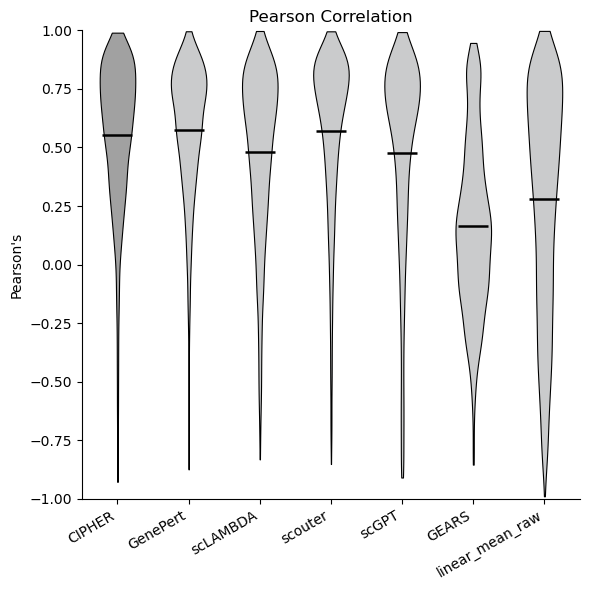

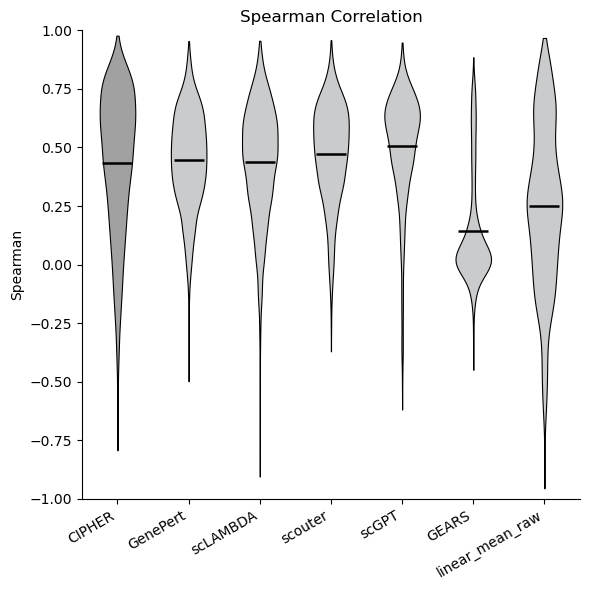

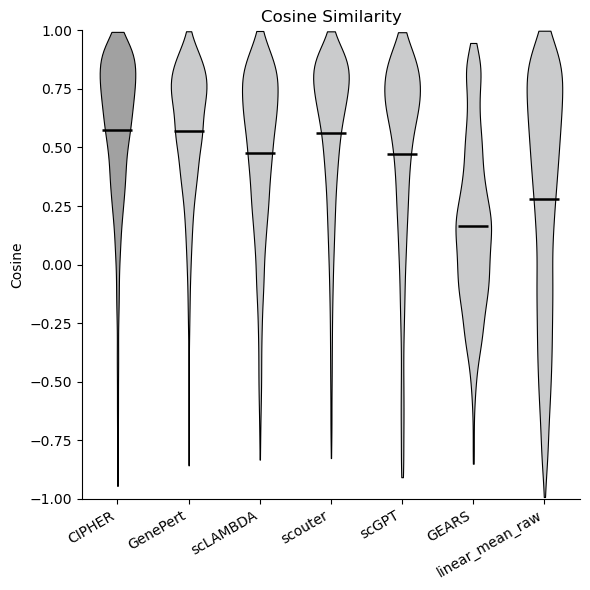

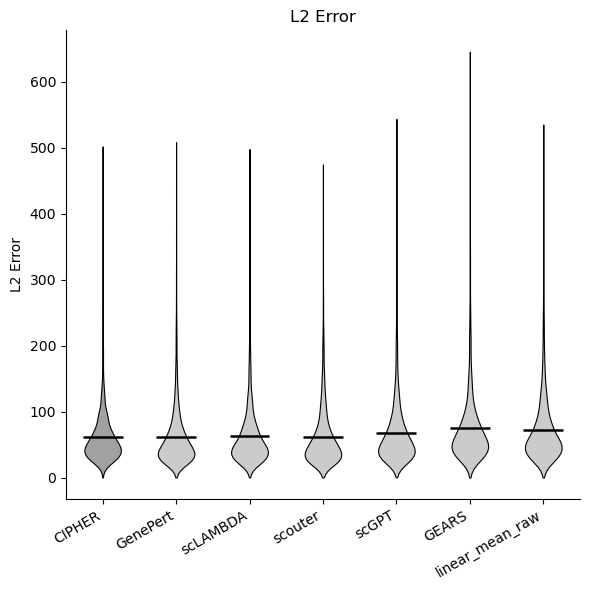

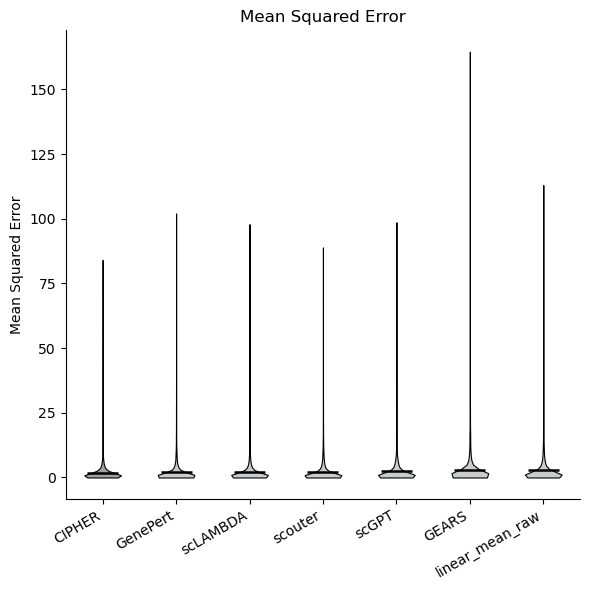

In [3]:
R.plot_metric_violins()

### Centroid accuracy (Systema)
For each perturbation, the fraction of *other* perturbations whose ground-truth centroid is farther from the prediction than the perturbation's own ground-truth centroid — a specificity measure that rewards predictions closest to the correct target.

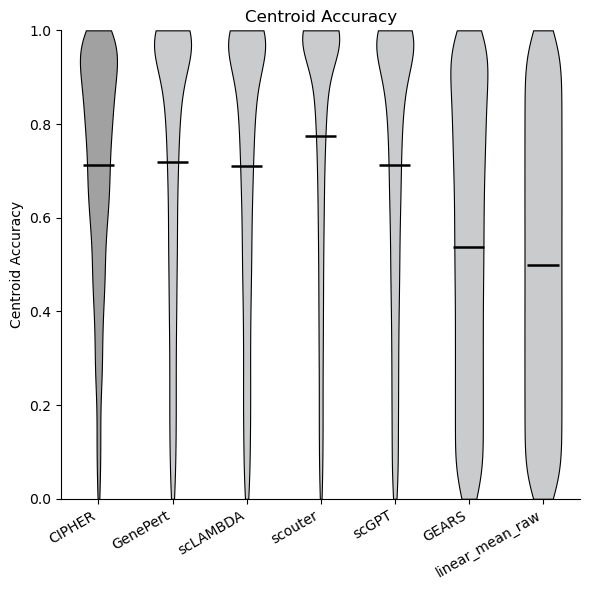

In [4]:
R.plot_centroid()